# Parte 2: Surrogate Model — D(w, θ) → (X̂_s, X̂_v)

**Contexto en el pipeline completo:**
```
Este notebook                            Siguiente notebook
──────────────────────────────────────   ──────────────────────────────────
[W, T] → [ Surrogate D ] → [X̂_s, X̂_v]  →  UKF usa D como función de medición
                                              para estimar θ̂ desde X_s real
```

## ¿Qué es el surrogate model y para qué sirve?

El motor turbofan real sigue leyes termodinámicas: dado un estado de salud θ y unas condiciones de vuelo w, los sensores X_s toman valores determinados por esa física. El simulador CMAPSS de NASA implementa esas ecuaciones, pero es código propietario al que no tenemos acceso.

El **surrogate model D** es una red neuronal (MLP) que **aprende esa misma relación desde los datos**:

```
D(w(t), θ(t))  →  (X̂_s(t), X̂_v(t))
```

Podemos entrenarlo porque el N-CMAPSS ya incluye los valores verdaderos de θ (variable `T`), w (`W`), X_s (`X_s`) y X_v (`X_v`).

## ¿Por qué D es un mapping ESTÁTICO (sin ventana temporal)?

El UKF (siguiente notebook) necesita una función **h(θ)**: *"dado este estado de salud θ y estas condiciones de vuelo w, ¿qué sensor debería leer?"*. Esta función debe ser evaluable punto a punto, sin depender de timesteps anteriores. Por eso el surrogate es un MLP estático, no una RNN o CNN.

## Arquitectura (paper, Appendix B)
```
Input:  [W(4) | T(10)]  =  14 features  
─────────────────────────────────────────
Linear(14 → 100)  → ReLU
Linear(100 → 100) → ReLU
Linear(100 → 100) → ReLU  
Linear(100 → 100) → ReLU
Linear(100 → 28)
─────────────────────────────────────────
Output: [X̂_s(14) | X̂_v(14)]  =  28 features
```
~34,600 parámetros entrenables.

## Outputs del notebook
Al final guardamos dos archivos que el notebook del UKF necesitará:
- `surrogate_model.pt` — pesos de la red entrenada
- `surrogate_scalers.pkl` — scalers de normalización (input y output)

---
## Celda 1: Imports y dispositivo

In [1]:
import os
import h5py
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ─── Dispositivo ──────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ GPU CUDA: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('✓ Apple Silicon GPU (MPS)')
else:
    DEVICE = torch.device('cpu')
    print('✓ CPU')

print(f'  Dispositivo: {DEVICE} | PyTorch {torch.__version__}')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

✓ CPU
  Dispositivo: cpu | PyTorch 2.2.2


---
## Celda 2: Hiperparámetros del surrogate

In [2]:
FILENAME = 'N-CMAPSS_DS02-006.h5'  # Ajustar ruta si es necesario

# ─── Arquitectura MLP ─────────────────────────────────────────────────────────
HIDDEN_UNITS = 100    # Unidades por capa oculta (paper: 100)
N_HIDDEN     = 4      # Número de capas ocultas (paper: 4)

# ─── Entrenamiento ────────────────────────────────────────────────────────────
BATCH_SIZE   = 4096   # Grande porque las muestras son i.i.d. (sin ventana temporal)
LR           = 1e-3
MAX_EPOCHS   = 50
PATIENCE     = 5
VAL_FRACTION = 0.15   # 15% del dev set para validación del surrogate

print('Hiperparámetros surrogate model:')
print(f'  Arquitectura  : MLP [{HIDDEN_UNITS}×{N_HIDDEN}]')
print(f'  Batch size    : {BATCH_SIZE:,}')
print(f'  Learning rate : {LR}')
print(f'  Early stopping: {PATIENCE} épocas')

Hiperparámetros surrogate model:
  Arquitectura  : MLP [100×4]
  Batch size    : 4,096
  Learning rate : 0.001
  Early stopping: 5 épocas


---
## Celda 3: Carga de datos

Para entrenar el surrogate solo necesitamos el **dev set**. El test set no se toca aquí.

In [3]:
def decode_varnames(hdf, key):
    raw = np.array(hdf.get(key))
    if raw.dtype.kind in ('S', 'O'):
        return [v.decode('utf-8') if isinstance(v, bytes) else str(v) for v in raw]
    return list(np.array(raw, dtype='U20'))

t0 = time.time()

with h5py.File(FILENAME, 'r') as hdf:
    W_dev   = np.array(hdf.get('W_dev'),   dtype=np.float32)
    X_s_dev = np.array(hdf.get('X_s_dev'), dtype=np.float32)
    X_v_dev = np.array(hdf.get('X_v_dev'), dtype=np.float32)
    T_dev   = np.array(hdf.get('T_dev'),   dtype=np.float32)
    A_dev   = np.array(hdf.get('A_dev'),   dtype=np.float32)

    W_var   = decode_varnames(hdf, 'W_var')
    X_s_var = decode_varnames(hdf, 'X_s_var')
    X_v_var = decode_varnames(hdf, 'X_v_var')
    T_var   = decode_varnames(hdf, 'T_var')
    A_var   = decode_varnames(hdf, 'A_var')

print(f'Datos cargados en {time.time()-t0:.1f}s')
print(f'  W   : {W_dev.shape}   → {W_var}')
print(f'  X_s : {X_s_dev.shape}')
print(f'  X_v : {X_v_dev.shape}')
print(f'  T   : {T_dev.shape}')
print(f'  T_var (primeros 5): {T_var[:5]}')

units_dev = np.unique(A_dev[:, 0]).astype(int)
print(f'  Unidades dev: {units_dev}')

# Dimensiones
W_DIM   = W_dev.shape[1]    # 4
XS_DIM  = X_s_dev.shape[1]  # 14
XV_DIM  = X_v_dev.shape[1]  # 14
T_DIM   = T_dev.shape[1]    # 10

INPUT_DIM  = W_DIM + T_DIM      # 14  → lo que entra al surrogate
OUTPUT_DIM = XS_DIM + XV_DIM    # 28  → lo que predice el surrogate

print(f'\nDimensiones surrogate:')
print(f'  Input  [W|T] : {INPUT_DIM}')
print(f'  Output [X_s|X_v]: {OUTPUT_DIM}')

Datos cargados en 9.0s
  W   : (5263447, 4)   → ['alt', 'Mach', 'TRA', 'T2']
  X_s : (5263447, 14)
  X_v : (5263447, 14)
  T   : (5263447, 10)
  T_var (primeros 5): ['fan_eff_mod', 'fan_flow_mod', 'LPC_eff_mod', 'LPC_flow_mod', 'HPC_eff_mod']
  Unidades dev: [ 2  5 10 16 18 20]

Dimensiones surrogate:
  Input  [W|T] : 14
  Output [X_s|X_v]: 28


---
## Celda 4: Preparación de los datos de entrenamiento

El surrogate **no necesita ventana temporal**. Cada fila es una muestra independiente:
- Input `x_in[i]` = `[W[i], T[i]]` — condiciones operativas y salud en el timestep i
- Target `x_out[i]` = `[X_s[i], X_v[i]]` — sensores que el motor "debería" leer dado ese estado

Con ~5.3M de muestras en el dev set, tenemos datos más que suficientes.

In [4]:
# ─── Construir input y output del surrogate ───────────────────────────────────
X_in_raw  = np.concatenate([W_dev, T_dev], axis=1)          # (N, 14)
X_out_raw = np.concatenate([X_s_dev, X_v_dev], axis=1)      # (N, 28)

print(f'Input surrogate  X_in_raw  : {X_in_raw.shape}')
print(f'Output surrogate X_out_raw : {X_out_raw.shape}')

# ─── Normalización: scalers SEPARADOS para input y output ─────────────────────
# ¡IMPORTANTE! Necesitamos dos scalers distintos porque:
#   - El input [W, T] y el output [X_s, X_v] tienen rangos completamente diferentes
#   - Los scalers se guardan para usarlos en el UKF (donde solo tenemos W y necesitamos
#     des-normalizar la predicción de X_s para comparar con los sensores reales)

# Dividir train/val ANTES de fit del scaler (sin data leakage)
N_total = X_in_raw.shape[0]
N_val   = int(N_total * VAL_FRACTION)

# Mezclamos aleatoriamente (aquí SÍ podemos mezclar, porque el surrogate
# aprende una función estática, no dependencias temporales)
rng = np.random.default_rng(SEED)
idx = rng.permutation(N_total)
idx_train = idx[N_val:]
idx_val   = idx[:N_val]

X_in_train_raw  = X_in_raw[idx_train]
X_out_train_raw = X_out_raw[idx_train]
X_in_val_raw    = X_in_raw[idx_val]
X_out_val_raw   = X_out_raw[idx_val]

# Fit de scalers solo en train
scaler_in  = MinMaxScaler(feature_range=(-1, 1))
scaler_out = MinMaxScaler(feature_range=(-1, 1))

X_in_train  = scaler_in.fit_transform(X_in_train_raw)
X_out_train = scaler_out.fit_transform(X_out_train_raw)

X_in_val    = scaler_in.transform(X_in_val_raw)
X_out_val   = scaler_out.transform(X_out_val_raw)

print(f'\nDivisión:')
print(f'  Train : {X_in_train.shape[0]:>8,} muestras ({100*(1-VAL_FRACTION):.0f}%)')
print(f'  Val   : {X_in_val.shape[0]:>8,} muestras ({100*VAL_FRACTION:.0f}%)')
print(f'\nRangos tras normalización:')
print(f'  X_in_train  : [{X_in_train.min():.2f}, {X_in_train.max():.2f}]')
print(f'  X_out_train : [{X_out_train.min():.2f}, {X_out_train.max():.2f}]')

Input surrogate  X_in_raw  : (5263447, 14)
Output surrogate X_out_raw : (5263447, 28)

División:
  Train : 4,473,930 muestras (85%)
  Val   :  789,517 muestras (15%)

Rangos tras normalización:
  X_in_train  : [-1.00, 1.00]
  X_out_train : [-1.00, 1.00]


---
## Celda 5: Dataset y DataLoaders PyTorch

Como las muestras son i.i.d. (independientes), usamos `TensorDataset` directamente — no hace falta una clase personalizada como en el notebook de la CNN.

In [ ]:
# En esta celda solo preparamos los datos, sin crear el modelo ni entrenar. Por eso no hay data leakage,
# y podemos mezclar aleatoriamente las muestras para que el surrogate vea una distribución más uniforme
# durante el entrenamiento. El surrogate no aprende dependencias temporales, sino una función estática que mapea
#  Convertir a tensores PyTorch
T_in_train  = torch.tensor(X_in_train,  dtype=torch.float32)
T_out_train = torch.tensor(X_out_train, dtype=torch.float32)
T_in_val    = torch.tensor(X_in_val,    dtype=torch.float32)
T_out_val   = torch.tensor(X_out_val,   dtype=torch.float32)

train_dataset = TensorDataset(T_in_train, T_out_train)
val_dataset   = TensorDataset(T_in_val,   T_out_val)

N_WORKERS = 0 if str(DEVICE) in ['cpu', 'mps'] else 4
PIN_MEM   = (str(DEVICE) == 'cuda')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=N_WORKERS, pin_memory=PIN_MEM)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE * 2,
                          shuffle=False, num_workers=N_WORKERS, pin_memory=PIN_MEM)

print(f'DataLoaders creados:')
print(f'  Train batches : {len(train_loader):,}')
print(f'  Val batches   : {len(val_loader):,}')

# Verificar un batch
xb, yb = next(iter(train_loader))
print(f'\nForma de un batch:')
print(f'  Input  x: {xb.shape}  → (batch, 14)')
print(f'  Output y: {yb.shape}  → (batch, 28)')

DataLoaders creados:
  Train batches : 1,093
  Val batches   : 97

Forma de un batch:
  Input  x: torch.Size([4096, 14])  → (batch, 14)
  Output y: torch.Size([4096, 28])  → (batch, 28)


---
## Celda 6: Arquitectura del Surrogate Model (MLP)

El MLP aprende la función termodinámica del motor: dadas las condiciones de vuelo y el estado de salud, ¿qué leen los sensores?

In [6]:
class SurrogateModel(nn.Module):
    """
    MLP que aproxima la función del simulador CMAPSS:
        D(w, θ)  →  (X̂_s, X̂_v)
    
    Esta red es el "corazón" del UKF: el UKF la usa como función de medición
    para predecir qué sensores debería leer dado un estado de salud θ estimado.
    
    Input shape:  (batch, 14)   → [W(4) | T(10)]
    Output shape: (batch, 28)   → [X̂_s(14) | X̂_v(14)]
    """
    
    def __init__(self, input_dim, output_dim, hidden_units=100, n_hidden=4):
        super(SurrogateModel, self).__init__()
        
        # Construir capas dinámicamente según n_hidden
        layers = []
        in_size = input_dim
        for _ in range(n_hidden):
            layers.append(nn.Linear(in_size, hidden_units))
            layers.append(nn.ReLU())
            in_size = hidden_units
        layers.append(nn.Linear(hidden_units, output_dim))
        # Sin activación final: regresión, el output puede ser cualquier valor en [-1, 1]
        
        self.net = nn.Sequential(*layers)
        
        # Inicialización de pesos (Glorot/Xavier — buena práctica para MLPs de regresión)
        self._init_weights()
        
        # Resumen
        n_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'SurrogateModel inicializado:')
        print(f'  Arquitectura: {input_dim} → [{hidden_units}]×{n_hidden} → {output_dim}')
        print(f'  Parámetros  : {n_params:,}')
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)
    
    def predict_xs(self, x):
        """Devuelve solo la predicción de X_s (primeras XS_DIM columnas del output).
        Conveniente para el UKF, que solo compara X_s predicho vs X_s observado."""
        return self.forward(x)[:, :XS_DIM]


surrogate = SurrogateModel(
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_units=HIDDEN_UNITS,
    n_hidden=N_HIDDEN
).to(DEVICE)

# Prueba de forward pass
with torch.no_grad():
    x_test = torch.randn(8, INPUT_DIM).to(DEVICE)
    y_test = surrogate(x_test)
    print(f'\nForward pass: {x_test.shape} → {y_test.shape} ✓')

SurrogateModel inicializado:
  Arquitectura: 14 → [100]×4 → 28
  Parámetros  : 34,628

Forward pass: torch.Size([8, 14]) → torch.Size([8, 28]) ✓


---
## Celda 7: Entrenamiento

Misma lógica de entrenamiento que el notebook anterior: MSE loss, AMSGrad, early stopping.

**Detalle sobre la loss para el surrogate:** Entrenamos con una sola MSE sobre las 28 salidas concatenadas. Esto trata X_s y X_v con igual peso. Si quisieras dar más importancia a X_s (que es lo que el UKF observa), podrías usar una loss ponderada, pero el paper no lo especifica así.

In [7]:
def train_surrogate(model, train_loader, val_loader, device,
                    lr=1e-3, max_epochs=50, patience=5,
                    checkpoint_path='surrogate_best.pt'):
    """
    Loop de entrenamiento con early stopping para el surrogate model.
    Devuelve historial de losses.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, amsgrad=True)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    
    history = {'train_loss': [], 'val_loss': [],
               'train_rmse_xs': [], 'val_rmse_xs': []}  # también trackeamos RMSE solo de X_s
    best_val_loss  = float('inf')
    patience_count = 0
    
    print(f'Entrenando SurrogateModel en {device}')
    print(f'{"Época":>6}  {"Train MSE":>10}  {"Val MSE":>10}  {"Val RMSE(X_s)":>14}')
    print('-' * 50)
    
    for epoch in range(1, max_epochs + 1):
        # ── TRAIN ────────────────────────────────────────────────────────────
        model.train()
        t_loss_sum, n_t = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            t_loss_sum += loss.item(); n_t += 1
        train_loss = t_loss_sum / n_t
        
        # ── VALIDATION ───────────────────────────────────────────────────────
        model.eval()
        v_loss_sum, n_v = 0.0, 0
        v_preds_xs, v_true_xs = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                v_loss_sum += criterion(pred, yb).item(); n_v += 1
                # Guardamos solo X_s (primeras XS_DIM columnas) para RMSE separado
                v_preds_xs.append(pred[:, :XS_DIM].cpu())
                v_true_xs.append(yb[:, :XS_DIM].cpu())
        
        val_loss = v_loss_sum / n_v
        scheduler.step(val_loss)
        
        # RMSE solo en X_s (en espacio normalizado [-1,1])
        vp_xs = torch.cat(v_preds_xs).numpy()
        vt_xs = torch.cat(v_true_xs).numpy()
        val_rmse_xs = np.sqrt(mean_squared_error(vt_xs, vp_xs))
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_rmse_xs'].append(val_rmse_xs)
        
        # ── CHECKPOINT + EARLY STOPPING ──────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_count = 0
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_loss': val_loss}, checkpoint_path)
            marker = ' ◀'
        else:
            patience_count += 1
            marker = f' ({patience_count}/{patience})'
        
        print(f'{epoch:>6}  {train_loss:>10.5f}  {val_loss:>10.5f}  {val_rmse_xs:>14.5f}{marker}')
        
        if patience_count >= patience:
            print(f'\nEarly stopping en época {epoch}.')
            break
    
    # Cargar mejor checkpoint
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'\nMejor modelo: época {ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.6f}')
    return history


history = train_surrogate(
    surrogate, train_loader, val_loader,
    device=DEVICE, lr=LR, max_epochs=MAX_EPOCHS, patience=PATIENCE
)

/Users/mac/Documents/Programs/Tendencias/torch-env/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Entrenando SurrogateModel en cpu
 Época   Train MSE     Val MSE   Val RMSE(X_s)
--------------------------------------------------
     1     0.00240     0.00048         0.02152 ◀
     2     0.00005     0.00002         0.00434 ◀
     3     0.00003     0.00002         0.00418 ◀
     4     0.00002     0.00001         0.00334 ◀
     5     0.00002     0.00002         0.00447 (1/5)
     6     0.00001     0.00002         0.00356 (2/5)
     7     0.00001     0.00001         0.00284 ◀
     8     0.00001     0.00001         0.00295 (1/5)
     9     0.00001     0.00001         0.00266 ◀
    10     0.00001     0.00001         0.00266 (1/5)
    11     0.00001     0.00001         0.00316 (2/5)
    12     0.00001     0.00001         0.00259 ◀
    13     0.00001     0.00001         0.00245 ◀
    14     0.00001     0.00001         0.00245 (1/5)
    15     0.00001     0.00001         0.00269 (2/5)
    16     0.00001     0.00001         0.00234 ◀
    17     0.00001     0.00001         0.00246 (1/5)
    

---
## Celda 8: Curvas de aprendizaje

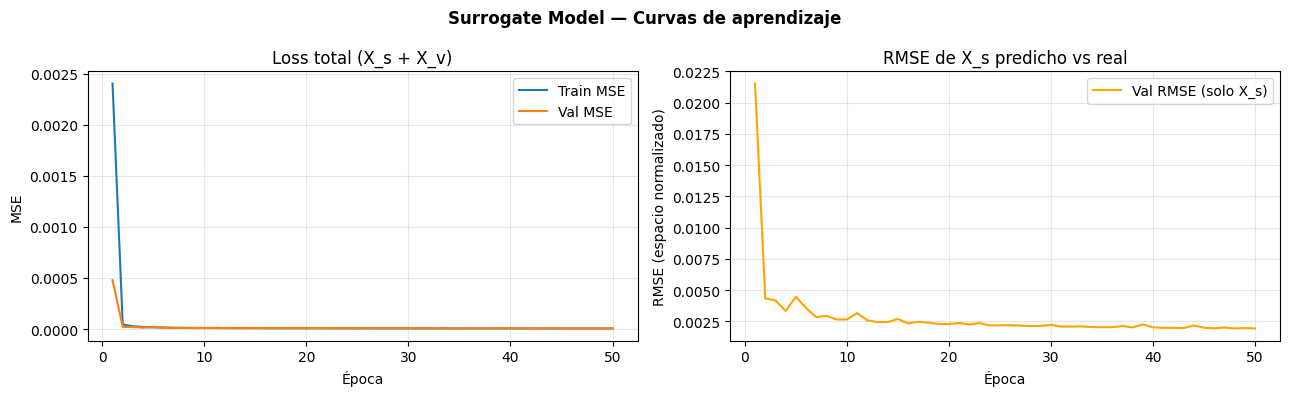

Val MSE final  : 0.000006
Val RMSE X_s   : 0.001935  (espacio normalizado [-1,1])


In [9]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train MSE')
ax.plot(epochs, history['val_loss'],   label='Val MSE')
ax.set_xlabel('Época'); ax.set_ylabel('MSE')
ax.set_title('Loss total (X_s + X_v)'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs, history['val_rmse_xs'], color='orange', label='Val RMSE (solo X_s)')
ax.set_xlabel('Época'); ax.set_ylabel('RMSE (espacio normalizado)')
ax.set_title('RMSE de X_s predicho vs real'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Surrogate Model — Curvas de aprendizaje', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Val MSE final  : {history["val_loss"][-1]:.6f}')
print(f'Val RMSE X_s   : {history["val_rmse_xs"][-1]:.6f}  (espacio normalizado [-1,1])')

---
## Celda 9: Evaluación en espacio original (des-normalizado)

Las métricas en espacio normalizado [-1, 1] son difíciles de interpretar. Aquí transformamos las predicciones al espacio original de los sensores para ver el error real en las unidades físicas del dataset.

In [10]:
# Predicciones en todo el val set
surrogate.eval()
all_preds_norm, all_true_norm = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        pred = surrogate(xb.to(DEVICE)).cpu().numpy()
        all_preds_norm.append(pred)
        all_true_norm.append(yb.numpy())

preds_norm = np.vstack(all_preds_norm)  # (N_val, 28)
trues_norm = np.vstack(all_true_norm)   # (N_val, 28)

# Des-normalizar usando el scaler de output (entrenado sobre [X_s, X_v] concatenados)
preds_orig = scaler_out.inverse_transform(preds_norm)  # (N_val, 28)
trues_orig = scaler_out.inverse_transform(trues_norm)  # (N_val, 28)

# Separar X_s y X_v
preds_xs = preds_orig[:, :XS_DIM]    # (N_val, 14)
trues_xs = trues_orig[:, :XS_DIM]
preds_xv = preds_orig[:, XS_DIM:]    # (N_val, 14)
trues_xv = trues_orig[:, XS_DIM:]

# ─── R² por canal de sensor ───────────────────────────────────────────────────
print('=== R² por canal de X_s (espacio original) ===')
print(f'{"Canal":<20}  {"R²":>8}  {"RMSE":>10}')
print('-' * 42)
r2_xs_list = []
for j in range(XS_DIM):
    name = X_s_var[j] if X_s_var else f'X_s_{j}'
    r2   = r2_score(trues_xs[:, j], preds_xs[:, j])
    rmse = np.sqrt(mean_squared_error(trues_xs[:, j], preds_xs[:, j]))
    r2_xs_list.append(r2)
    marker = ' ✓' if r2 > 0.95 else (' ?' if r2 > 0.80 else ' ✗')
    print(f'{name:<20}  {r2:>8.4f}  {rmse:>10.4f}{marker}')

print(f'\nR² promedio X_s: {np.mean(r2_xs_list):.4f}')
print(f'R² mínimo  X_s: {np.min(r2_xs_list):.4f}')

print('\n=== R² por canal de X_v (espacio original) ===')
print(f'{"Canal":<20}  {"R²":>8}')
print('-' * 32)
r2_xv_list = []
for j in range(XV_DIM):
    name = X_v_var[j] if X_v_var else f'X_v_{j}'
    r2   = r2_score(trues_xv[:, j], preds_xv[:, j])
    r2_xv_list.append(r2)
    marker = ' ✓' if r2 > 0.95 else (' ?' if r2 > 0.80 else ' ✗')
    print(f'{name:<20}  {r2:>8.4f}{marker}')

print(f'\nR² promedio X_v: {np.mean(r2_xv_list):.4f}')

=== R² por canal de X_s (espacio original) ===
Canal                       R²        RMSE
------------------------------------------
T24                     1.0000      0.1052 ✓
T30                     1.0000      0.3343 ✓
T48                     0.9998      1.2380 ✓
T50                     0.9994      1.2229 ✓
P15                     1.0000      0.0068 ✓
P2                      1.0000      0.0060 ✓
P21                     1.0000      0.0067 ✓
P24                     1.0000      0.0094 ✓
Ps30                    1.0000      0.2001 ✓
P40                     1.0000      0.1936 ✓
P50                     1.0000      0.0086 ✓
Nf                      1.0000      0.8062 ✓
Nc                      1.0000      0.9299 ✓
Wf                      0.9999      0.0043 ✓

R² promedio X_s: 0.9999
R² mínimo  X_s: 0.9994

=== R² por canal de X_v (espacio original) ===
Canal                       R²
--------------------------------
T40                     0.9998 ✓
P30                     1.0000 ✓
P45        

---
## Celda 10: Scatter plots — X_s predicho vs real

Cada punto es un timestep del val set. Una nube perfectamente en la diagonal indica predicción perfecta.

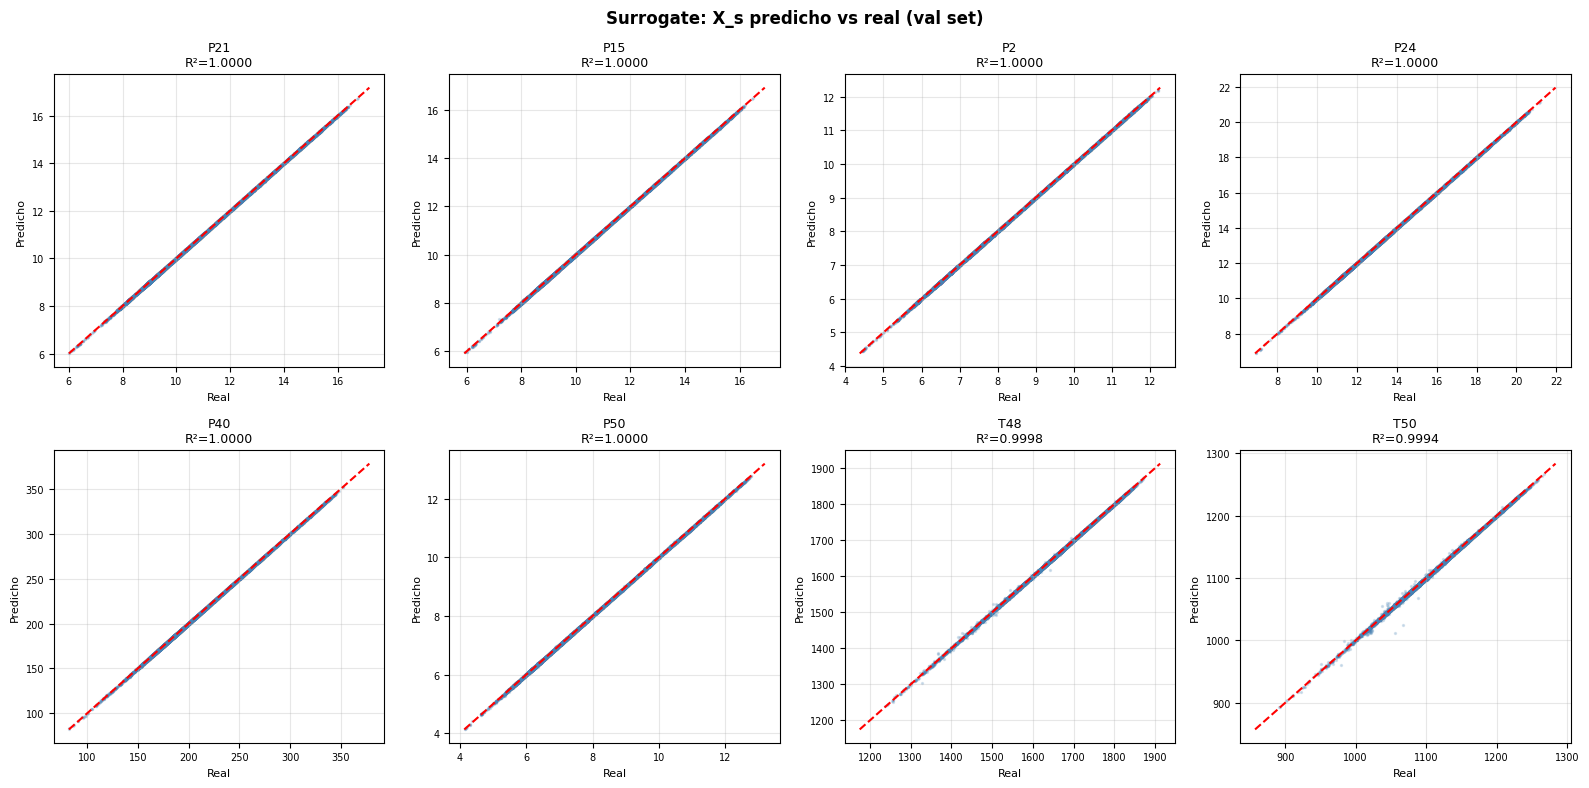

In [11]:
# Mostrar los 6 canales de X_s con mayor R² y los 2 con menor
sorted_idx = np.argsort(r2_xs_list)[::-1]   # de mayor a menor R²
channels_to_plot = list(sorted_idx[:6]) + list(sorted_idx[-2:])  # top 6 + bottom 2
n_plot = len(channels_to_plot)

# Subsamplear para el scatter (demasiados puntos enlentece el plot)
subsample = min(10000, len(preds_xs))
rng_idx = np.random.choice(len(preds_xs), subsample, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for k, j in enumerate(channels_to_plot):
    ax = axes[k]
    name = X_s_var[j] if X_s_var else f'X_s_{j}'
    r2 = r2_xs_list[j]
    
    ax.scatter(trues_xs[rng_idx, j], preds_xs[rng_idx, j],
               alpha=0.2, s=2, color='steelblue')
    
    # Línea perfecta
    lo = min(trues_xs[:, j].min(), preds_xs[:, j].min())
    hi = max(trues_xs[:, j].max(), preds_xs[:, j].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    
    ax.set_title(f'{name}\nR²={r2:.4f}', fontsize=9)
    ax.set_xlabel('Real', fontsize=8)
    ax.set_ylabel('Predicho', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

# Ocultar ejes sobrantes
for k in range(n_plot, len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Surrogate: X_s predicho vs real (val set)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Celda 11: Validación temporal — predicción a lo largo de un vuelo

Esta es la prueba más importante para el UKF: el surrogate debe capturar correctamente **cómo evolucionan los sensores a lo largo de los ciclos de vida del motor**. Comparamos la predicción temporal vs los sensores reales para una unidad completa.

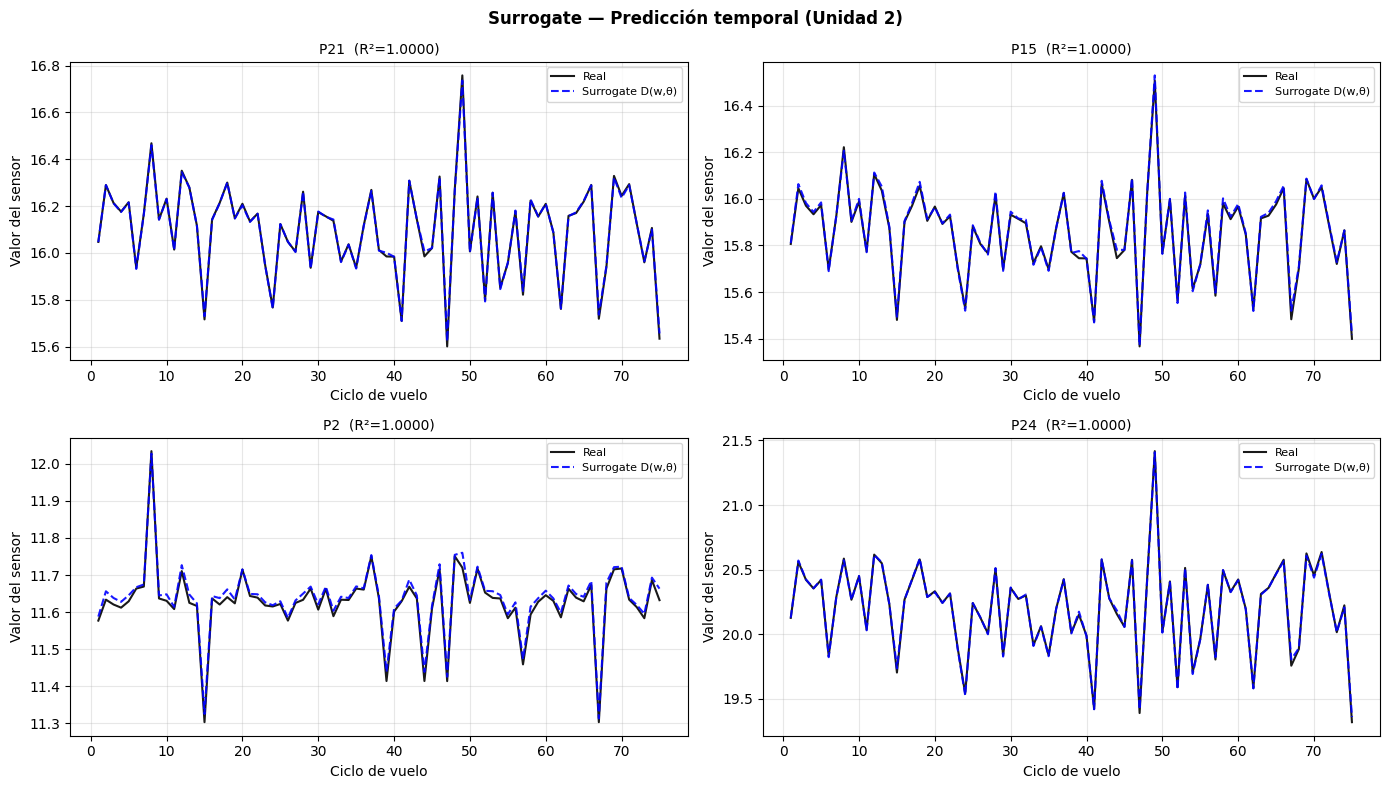

Si las curvas azules siguen de cerca las negras → el surrogate aprende bien la dinámica del motor.


In [12]:
# Tomar la primera unidad del dev set para la validación temporal
UNIT_DEMO = units_dev[0]
mask_demo = A_dev[:, 0] == UNIT_DEMO

W_demo   = W_dev[mask_demo]
T_demo   = T_dev[mask_demo]
X_s_demo = X_s_dev[mask_demo]
A_demo   = A_dev[mask_demo]

# Construir input y predecir
X_in_demo = np.concatenate([W_demo, T_demo], axis=1)
X_in_demo_norm = scaler_in.transform(X_in_demo)

surrogate.eval()
with torch.no_grad():
    pred_demo_norm = surrogate(
        torch.tensor(X_in_demo_norm, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

# Des-normalizar la predicción
# scaler_out fue entrenado sobre [X_s, X_v] concatenados
# pero aquí solo tenemos el output del surrogate que tiene 28 columnas, está bien
pred_demo_orig = scaler_out.inverse_transform(pred_demo_norm)
X_s_pred_demo  = pred_demo_orig[:, :XS_DIM]   # solo X_s

# Tomar 1 muestra por ciclo (primer timestep del ciclo) para claridad
cycles = A_demo[:, 1]
unique_cycles, first_idx = np.unique(cycles, return_index=True)

# Seleccionar 4 sensores para graficar
sensors_to_plot = sorted_idx[:4]  # los 4 de mayor R²
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for k, j in enumerate(sensors_to_plot):
    ax = axes[k]
    name = X_s_var[j] if X_s_var else f'X_s_{j}'
    
    ax.plot(unique_cycles, X_s_demo[first_idx, j],
            'k-', lw=1.5, label='Real', alpha=0.9)
    ax.plot(unique_cycles, X_s_pred_demo[first_idx, j],
            'b--', lw=1.5, label='Surrogate D(w,θ)', alpha=0.9)
    
    ax.set_title(f'{name}  (R²={r2_xs_list[j]:.4f})', fontsize=10)
    ax.set_xlabel('Ciclo de vuelo')
    ax.set_ylabel('Valor del sensor')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Surrogate — Predicción temporal (Unidad {UNIT_DEMO})',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
print('Si las curvas azules siguen de cerca las negras → el surrogate aprende bien la dinámica del motor.')

---
## Celda 12: Guardar el surrogate y los scalers

El UKF necesita **ambos archivos**:
- `surrogate_model.pt`: pesos de la red
- `surrogate_scalers.pkl`: `scaler_in` (para normalizar `[W, θ̂]` antes de entrar al surrogate) y `scaler_out` (para des-normalizar la predicción y comparar con `X_s` real)

In [13]:
# Guardar modelo
torch.save({
    'model_state_dict': surrogate.state_dict(),
    'config': {
        'input_dim'   : INPUT_DIM,
        'output_dim'  : OUTPUT_DIM,
        'hidden_units': HIDDEN_UNITS,
        'n_hidden'    : N_HIDDEN,
        'W_DIM'       : W_DIM,
        'XS_DIM'      : XS_DIM,
        'XV_DIM'      : XV_DIM,
        'T_DIM'       : T_DIM,
    },
    'metrics': {
        'r2_xs_mean': float(np.mean(r2_xs_list)),
        'r2_xv_mean': float(np.mean(r2_xv_list)),
        'val_loss'  : history['val_loss'][-1],
    }
}, 'surrogate_model.pt')

# Guardar scalers (pickle)
with open('surrogate_scalers.pkl', 'wb') as f:
    pickle.dump({
        'scaler_in' : scaler_in,   # normaliza [W, θ] → entrada al surrogate
        'scaler_out': scaler_out,  # normaliza/des-normaliza [X_s, X_v] → salida
        'var_names' : {
            'W_var'  : W_var,
            'X_s_var': X_s_var,
            'X_v_var': X_v_var,
            'T_var'  : T_var,
        }
    }, f)

print('Archivos guardados:')
print('  surrogate_model.pt     → pesos de la red')
print('  surrogate_scalers.pkl  → scalers de normalización')
print()
print('Estos dos archivos son los inputs del notebook del UKF.')

# Verificar que se puede cargar correctamente
ckpt_test = torch.load('surrogate_model.pt', map_location='cpu')
print(f'\nVerificación:')
print(f'  Config guardada    : {ckpt_test["config"]}')
print(f'  R² X_s (val)       : {ckpt_test["metrics"]["r2_xs_mean"]:.4f}')
print(f'  R² X_v (val)       : {ckpt_test["metrics"]["r2_xv_mean"]:.4f}')

Archivos guardados:
  surrogate_model.pt     → pesos de la red
  surrogate_scalers.pkl  → scalers de normalización

Estos dos archivos son los inputs del notebook del UKF.

Verificación:
  Config guardada    : {'input_dim': 14, 'output_dim': 28, 'hidden_units': 100, 'n_hidden': 4, 'W_DIM': 4, 'XS_DIM': 14, 'XV_DIM': 14, 'T_DIM': 10}
  R² X_s (val)       : 0.9999
  R² X_v (val)       : 0.9998


---
## Celda 13: Resumen e interpretación

**¿Qué tan bueno tiene que ser el surrogate?**

El surrogate no necesita ser perfecto — necesita ser suficientemente bueno para que el UKF pueda distinguir entre diferentes estados de degradación θ. El criterio práctico es:
- **R² > 0.90** en la mayoría de canales de X_s: el UKF podrá usarlo de forma confiable
- **R² > 0.70** aún puede funcionar: el UKF tendrá más incertidumbre pero seguirá convergiendo
- **R² < 0.50** en un canal: considera excluirlo de la función de medición del UKF

El paper reporta que el surrogate aprende la física del motor con alta fidelidad para las condiciones operativas del N-CMAPSS.

In [ ]:
print('=' * 60)
print('  RESUMEN DEL SURROGATE MODEL')
print('=' * 60)
print(f'  Arquitectura  : MLP {INPUT_DIM} → [100]×4 → {OUTPUT_DIM}')
print(f'  R² promedio X_s : {np.mean(r2_xs_list):.4f}')
print(f'  R² promedio X_v : {np.mean(r2_xv_list):.4f}')
print(f'  R² mínimo   X_s : {np.min(r2_xs_list):.4f}  ({X_s_var[int(np.argmin(r2_xs_list))]})')
print(f'  R² máximo   X_s : {np.max(r2_xs_list):.4f}  ({X_s_var[int(np.argmax(r2_xs_list))]})')
print()
print('  Canales X_s con R² < 0.90 (candidatos a revisar):')
for j, r2 in enumerate(r2_xs_list):
    if r2 < 0.90:
        name = X_s_var[j] if X_s_var else f'X_s_{j}'
        print(f'    {name:<20} R²={r2:.4f}')

print()
print('  SIGUIENTE PASO: Notebook del UKF')
print('  El UKF usa surrogate_model.pt + surrogate_scalers.pkl')
print('  para estimar θ̂(t) a partir de X_s(t) observado.')
print('=' * 60)

---
## Apéndice: ¿Cómo usará el UKF al surrogate?

Para que entiendas por qué el surrogate tiene exactamente este diseño, aquí el pseudocódigo del UKF:

```python
# En cada timestep t para un motor dado:

# 1. Tenemos una estimación actual de θ̂(t|t-1)  (estado predicho)
# 2. Observamos el sensor real: X_s_real = X_s[t]
# 3. Usamos el surrogate para predecir qué sensor debería leer:

x_in = normalize(concat(W[t], θ̂))          # [W, θ̂] → normalizado
X_s_pred = surrogate(x_in)[:XS_DIM]        # predice X_s esperado
X_s_pred = denormalize(X_s_pred)           # volver a espacio original

# 4. Calcular la innovación (error entre predicho y observado):
innovacion = X_s_real - X_s_pred

# 5. El UKF usa esa innovación para actualizar θ̂(t|t)
#    → Si X_s_pred > X_s_real, el motor está más degradado de lo estimado
#    → El UKF ajusta θ̂ hacia abajo (más degradación)
```

Este ciclo se repite en cada timestep, y θ̂(t) converge a la estimación correcta de los parámetros de salud reales.